In [210]:
import pandas as pd
import matplotlib.pyplot as plt
from database.adatabase import ADatabase
import matplotlib.dates as mdates
from database.adatabase import ADatabase
from extractor.alp_paper_extractor import ALPPaperExtractor
from datetime import datetime, timedelta
from tqdm import tqdm
import pandas as pd
import random

market = ADatabase("market")

C:\Users\eric\AppData\Local\Temp\ipykernel_13176\1446410200.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trades["cr"] = (trades["return"] + 1).cumprod()
C:\Users\eric\AppData\Local\Temp\ipykernel_13176\1446410200.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trades["br"] = trades["adjclose"].pct_change().cumsum() + 1


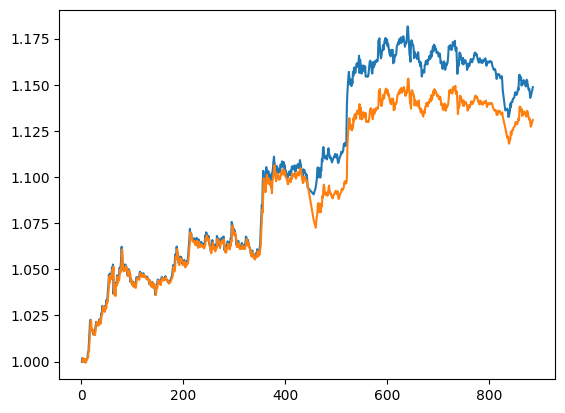

In [253]:
offset = 1
analysis = []
market = ADatabase("market")
market.connect()
df = market.retrieve("crypto").sort_values("date")
market.disconnect()
df.index = pd.to_datetime(df.index)
df["intrinsic"] = df["adjclose"].rolling(30).mean() - 2 * df["adjclose"].rolling(rolling).std()
df["signal"] = df["intrinsic"] < df["adjclose"]
# df["signal"] = True
df["buy_price"] = df["adjclose"]
df["sell_price"] = df["adjclose"].shift(-offset)
df["return"] = (df["sell_price"] - df["buy_price"]) / df["buy_price"]
df = df.dropna().reset_index(drop=True).iloc[1:].iloc[::offset]
trades = df[df["signal"]==True]
trades["cr"] = (trades["return"] + 1).cumprod()
trades["br"] = trades["adjclose"].pct_change().cumsum() + 1
plt.plot(trades["cr"])
plt.plot(trades["br"])
plt.show()
analysis.append({"rolling":rolling,"cr":trades["cr"].iloc[-1]})

In [254]:
df

,date,adjclose,ticker,intrinsic,signal,buy_price,sell_price,return
1,2024-02-08T22:30:00Z,45285.6000,BTC/USD,44633.820572,True,45285.6000,45279.2500,-0.000140
2,2024-02-08T22:45:00Z,45279.2500,BTC/USD,44631.757368,True,45279.2500,45370.7570,0.002021
3,2024-02-08T23:00:00Z,45370.7570,BTC/USD,44627.649467,True,45370.7570,45277.8515,-0.002048
4,2024-02-08T23:15:00Z,45277.8515,BTC/USD,44619.106765,True,45277.8515,45328.3625,0.001116
5,2024-02-08T23:30:00Z,45328.3625,BTC/USD,44617.418008,True,45328.3625,45295.5000,-0.000725
...,...,...,...,...,...,...,...,...
882,2024-02-18T02:45:00Z,51302.9050,BTC/USD,50957.118561,True,51302.9050,51352.3750,0.000964
883,2024-02-18T03:00:00Z,51352.3750,BTC/USD,50960.329267,True,51352.3750,51382.5100,0.000587
884,2024-02-18T03:15:00Z,51382.5100,BTC/USD,50967.155453,True,51382.5100,51455.6265,0.001423
885,2024-02-18T03:30:00Z,51455.6265,BTC/USD,50976.035267,True,51455.6265,51488.4800,0.000638
